In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load your dataset
df = pd.read_csv('data\\VisaFile.csv')

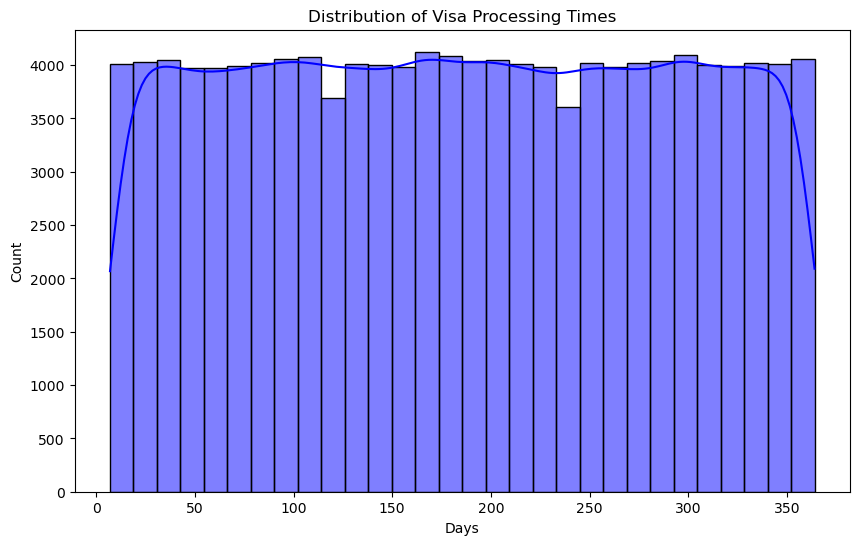

In [3]:
# --- A. Exploratory Data Analysis (EDA) ---

# Visualizing the distribution of Processing Time
plt.figure(figsize=(10, 6))
sns.histplot(df['processing_time_days'], kde=True, bins=30, color='blue')
plt.title('Distribution of Visa Processing Times')
plt.xlabel('Days')
plt.show()

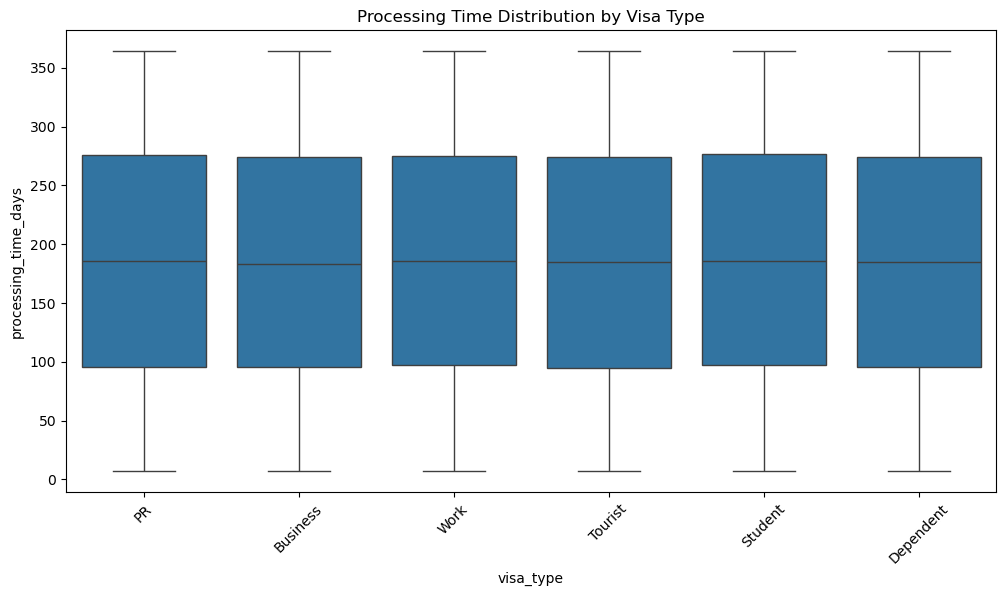

In [4]:
# Boxplot: Processing Time by Visa Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='visa_type', y='processing_time_days', data=df)
plt.title('Processing Time Distribution by Visa Type')
plt.xticks(rotation=45)
plt.show()

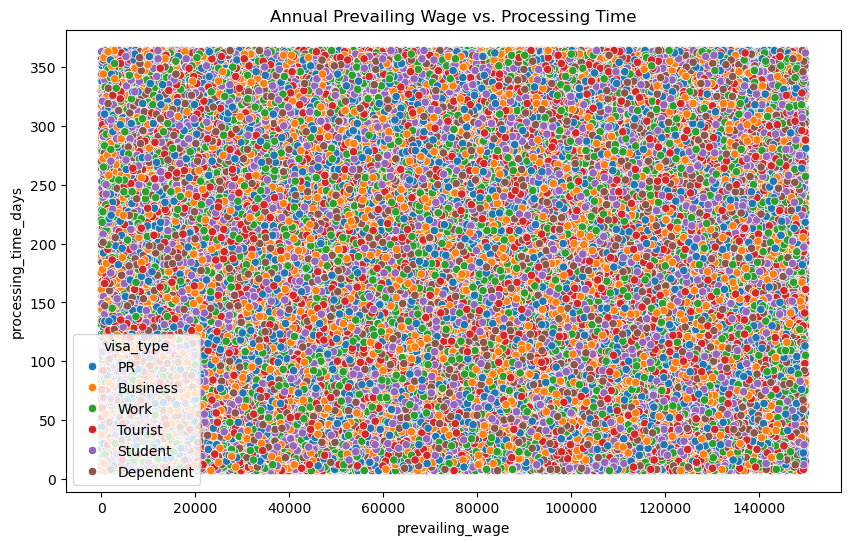

In [6]:
# Bivariate Analysis: Prevailing Wage vs. Processing Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='prevailing_wage', y='processing_time_days', hue='visa_type', data=df)
plt.title('Annual Prevailing Wage vs. Processing Time')
plt.show()

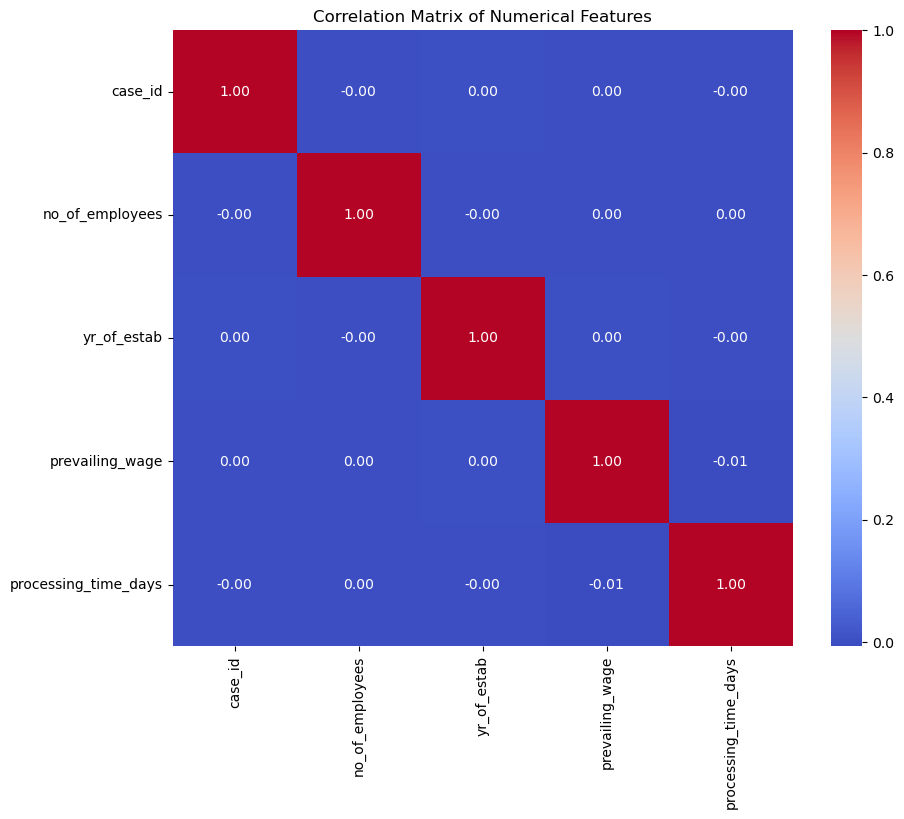

In [7]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [8]:
# --- B. Feature Engineering ---

# 1. Seasonal Index: Calculate mean processing time per season
seasonal_avg = df.groupby('application_season')['processing_time_days'].transform('mean')
df['seasonal_avg_time'] = seasonal_avg

In [9]:
# 2. Country-Specific Average: Mean processing time for each applicant country
country_avg = df.groupby('country_of_applicant')['processing_time_days'].transform('mean')
df['country_avg_time'] = country_avg

In [10]:
df = pd.get_dummies(df, columns=['continent', 'education_of_employee', 'processing_center'], drop_first=True)

print("Milestone 2 Complete. New features added:")
print(df[['seasonal_avg_time', 'country_avg_time']].head())

Milestone 2 Complete. New features added:
   seasonal_avg_time  country_avg_time
0         185.052400        187.242245
1         185.052400        185.614101
2         186.004864        184.707761
3         185.893569        183.247768
4         185.052400        183.247768
